In [16]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import os
import re
from pyproj import Transformer
from scipy.spatial import cKDTree
from sklearn.metrics import r2_score, mean_squared_error
from scipy.optimize import root
import netCDF4 as nc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import random

from grafi import (
    display_error_tables,
    display_winddir_met,
    display_cosine,
    plot_metric_res_2,
    plot_metric_res,
    plot_wind_comparison,
    plot_wind_speed_error_by_hour_multistation,
    plot_wind_speed_error_by_month_all_stations,
    plot_wind_errors_all_stations,
    plot_wdir_error_by_wspeed_all_stations,
    plot_absolute_wind_speed_error_windrose,
    compare_wind_plots_for_stations,
    plot_wind_speed_error_windrose,
    plot_absolute_wind_direction_error_windrose,
    plot_wind_direction_error_windrose,
    plot_wind_speed_comparison
)
from utils import (
    finalize_df,
    evaluate_model,
    prepare_observations,
    get_model_stations_data,
)
from postaje import (
    get_stations, get_names
)

In [17]:
base_path = "C:\\Users\\alex\\Desktop\\veter_data"

if not os.path.exists(base_path):
    print(f"{base_path} ne obstaja")

In [18]:
# meteopgt2021.all
file_2021 = os.path.join(base_path, 'meteopgt2021.all')
meteopgt_2021 = prepare_observations(file_2021, 2021)

# meteopgt2023.all
file_2023 = os.path.join(base_path, 'meteopgt2023.all')
meteopgt_2023 = prepare_observations(file_2023, 2023)

In [19]:
sns.set_theme(context='notebook', style='darkgrid', palette='deep', font='sans-serif', font_scale=1, color_codes=True, rc=None)

In [ ]:
base_path_250_2021 = os.path.join(base_path, "VeterPodatkiARSO", "2021")
if not os.path.exists(base_path_250_2021):
    print(f"{base_path_250_2021}' ne obstja")
stations = get_stations()
stations = get_model_stations_data(base_path_250_2021, stations, "025km_2021")
df_2021 = finalize_df(meteopgt_2021, stations)
results_2021 = evaluate_model(stations, df_2021)
    

base_path_250_2023 = os.path.join(base_path, "VeterPodatkiARSO", "2023")
if not os.path.exists(base_path_250_2023):
    print(f"{base_path_250_2023}' ne obstja")
stations = get_stations()
stations = get_model_stations_data(base_path_250_2023, stations, "025km_2023")
df_2023 = finalize_df(meteopgt_2023, stations)
results_2023 = evaluate_model(stations, df_2023)    

loaded
loaded


In [21]:
names = get_names()

df_both = pd.concat([df_2021, df_2023])
results_both = evaluate_model(get_stations(), df_both)
print(results_both)

               Name      MAE    RMSE   MAPE  Cosine      R2     Bias
0        bezigrad_u   0.2262  0.3415  24.34  0.7914  0.9303   0.0846
1        bezigrad_v   0.1765  0.2614  18.71  0.7914  0.9422   0.0518
2   bezigrad_WSpeed   0.2241  0.3404  19.10     NaN  0.9111  -0.0789
3     bezigrad_WDir  24.8030     NaN    NaN     NaN     NaN -10.0209
4           borst_u   0.2634  0.8761  33.11  0.8625  0.4666  -0.0674
5           borst_v   0.3195  0.7950  35.06  0.8625  0.5357  -0.0378
6      borst_WSpeed   0.3365  1.1344  29.52     NaN -0.0908  -0.2025
7        borst_WDir  20.7514     NaN    NaN     NaN     NaN   1.2481
8          let_lj_u   0.2200  0.3655  18.51  0.9335  0.9525  -0.0040
9          let_lj_v   0.1928  0.2732  20.48  0.9335  0.9430   0.0416
10    let_lj_WSpeed   0.2394  0.3828  17.08     NaN  0.9122  -0.1775
11      let_lj_WDir  12.5282     NaN    NaN     NaN     NaN   0.0163
12          pasja_u   0.8615  1.2400  79.39  0.7914  0.2461   0.0033
13          pasja_v   0.5748  0.93

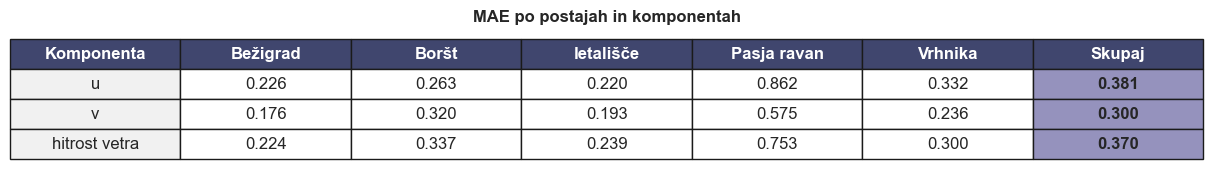

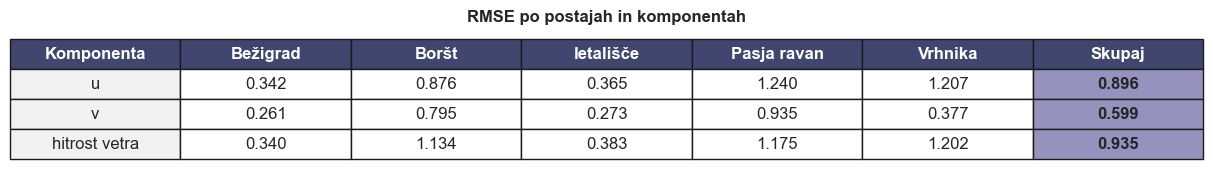

In [22]:
display_error_tables(results_both, stations, n=names)

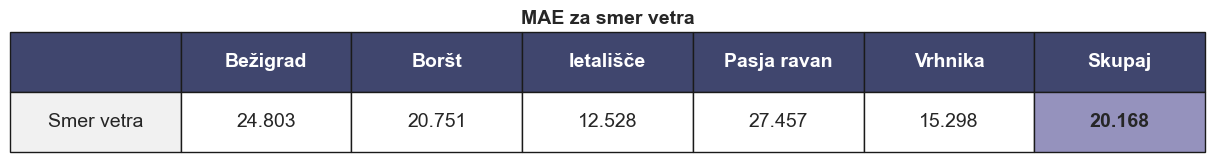

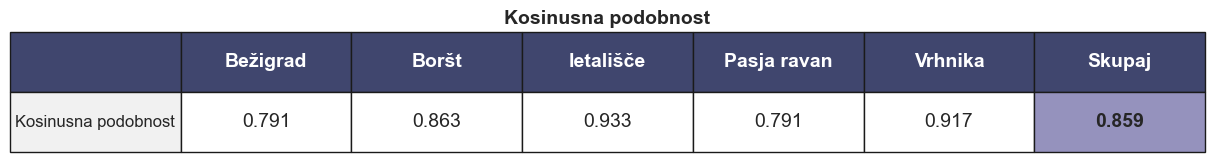

In [23]:
display_winddir_met(results_both, stations, names)
display_cosine(results_both, stations, names)

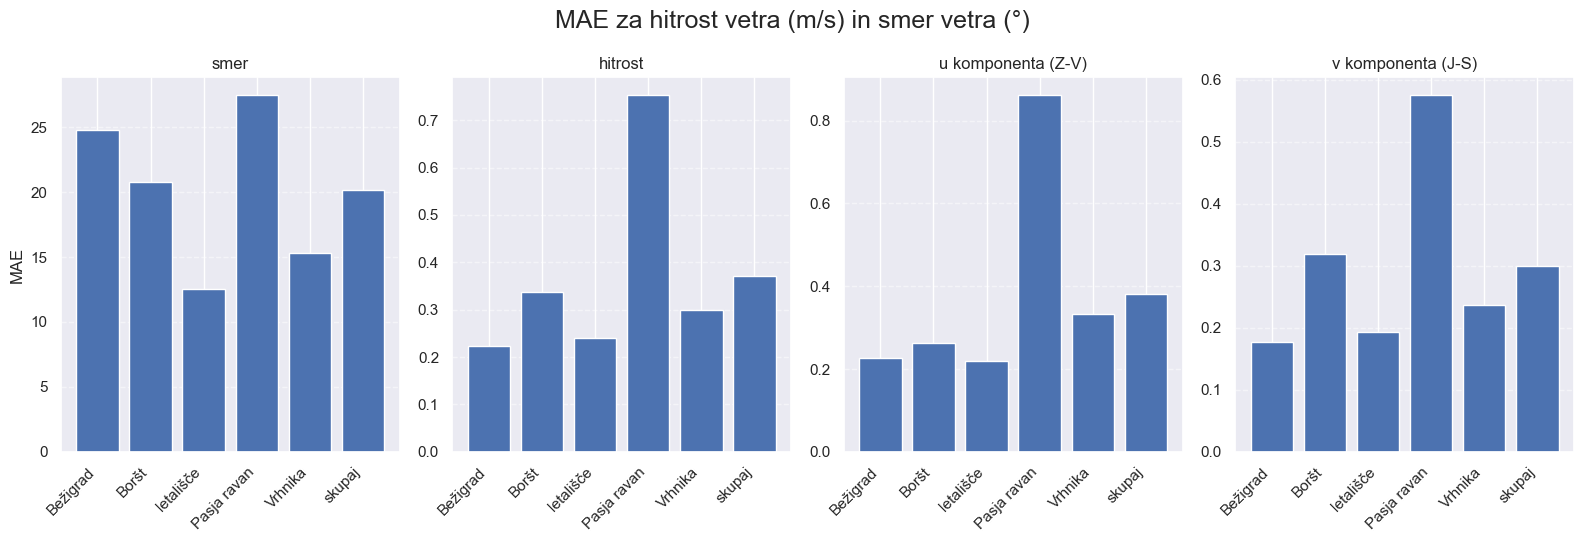

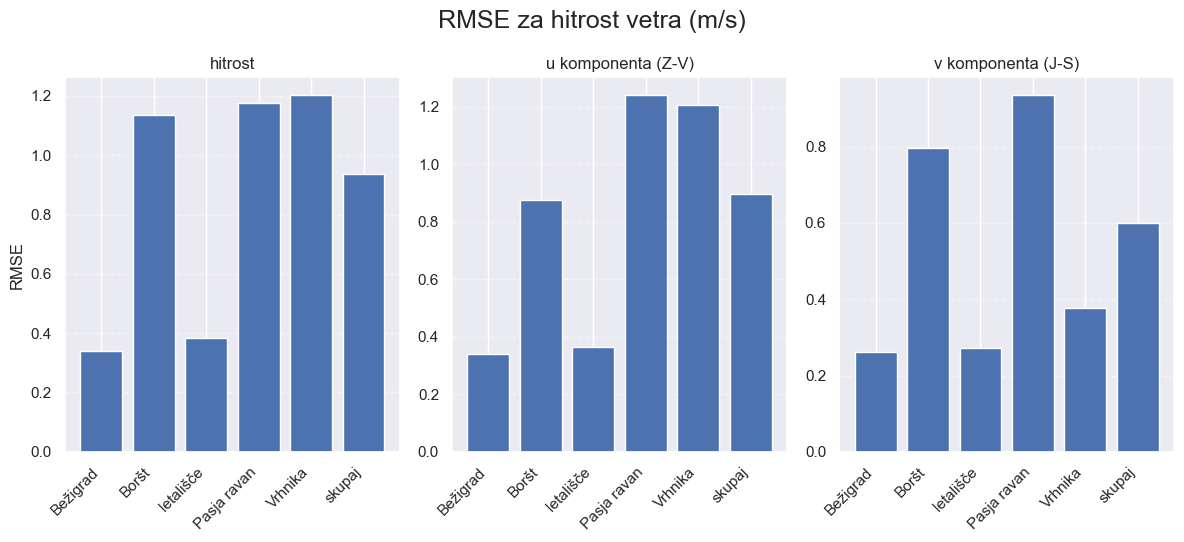

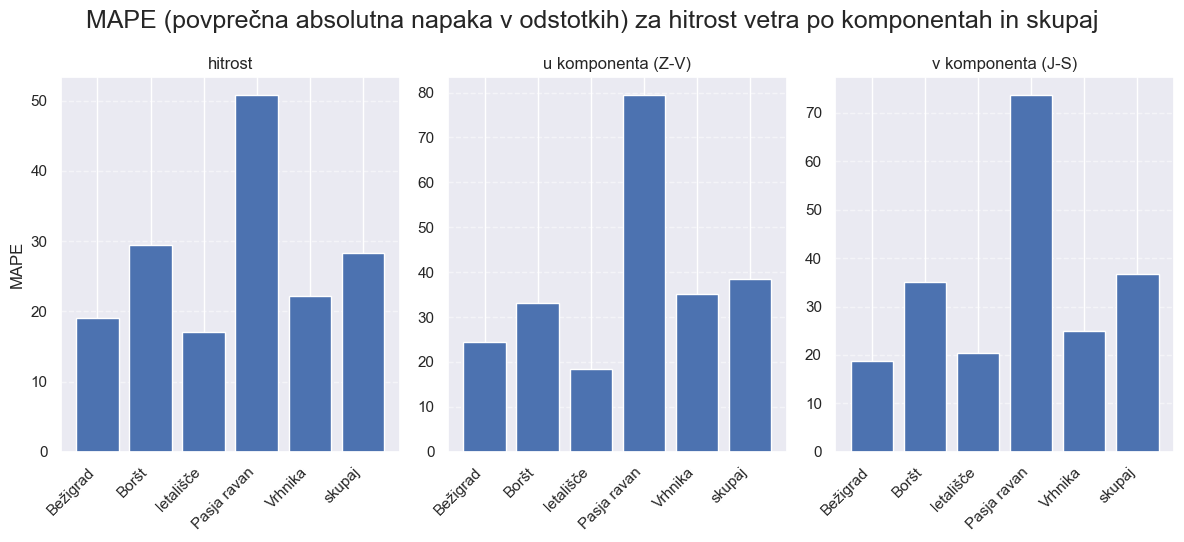

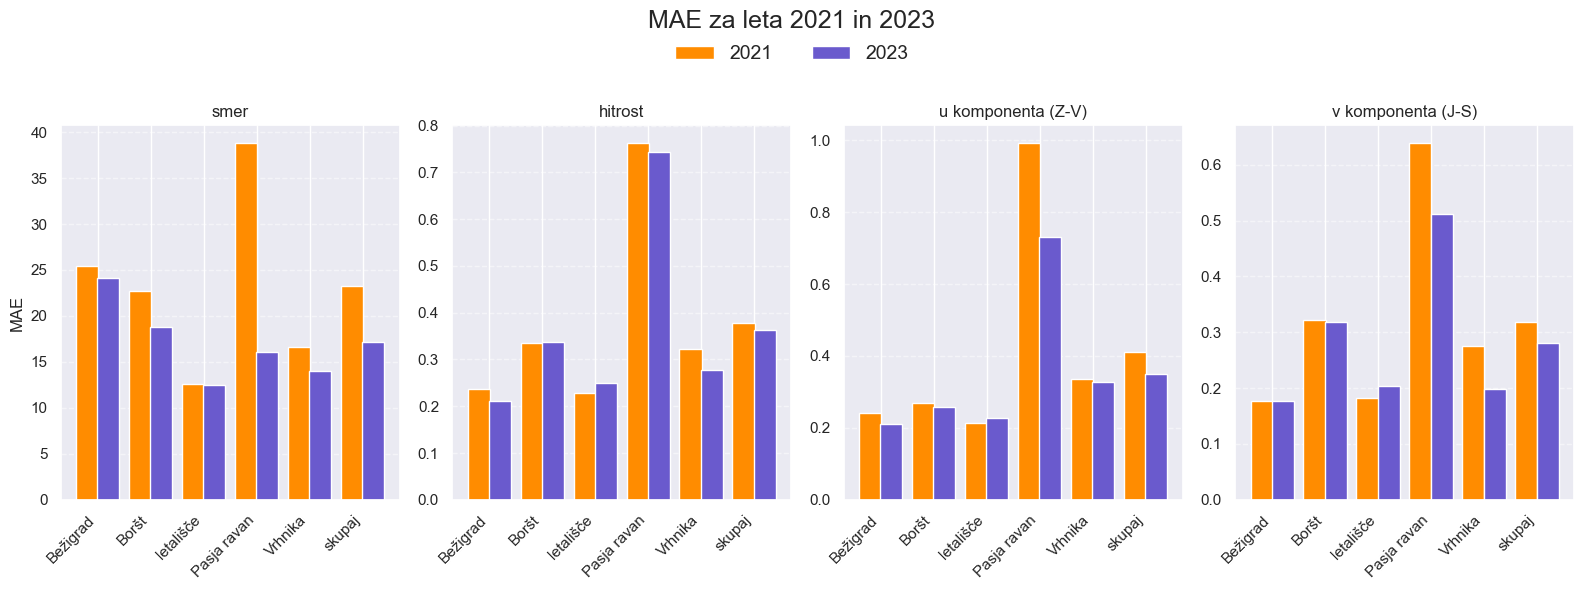

In [24]:
plot_metric_res(metric='MAE', df1=results_both, names=names, title='MAE za hitrost vetra (m/s) in smer vetra (°)')

plot_metric_res(metric='RMSE', df1=results_both, names=names, title='RMSE za hitrost vetra (m/s)', ign=["WDir"])

plot_metric_res(metric='MAPE', df1=results_both, names=names, title='MAPE (povprečna absolutna napaka v odstotkih) za hitrost vetra po komponentah in skupaj', ign=["WDir"])

plot_metric_res_2(metric='MAE', df1=results_2021, df2=results_2023, names=names, title='MAE za leta 2021 in 2023')

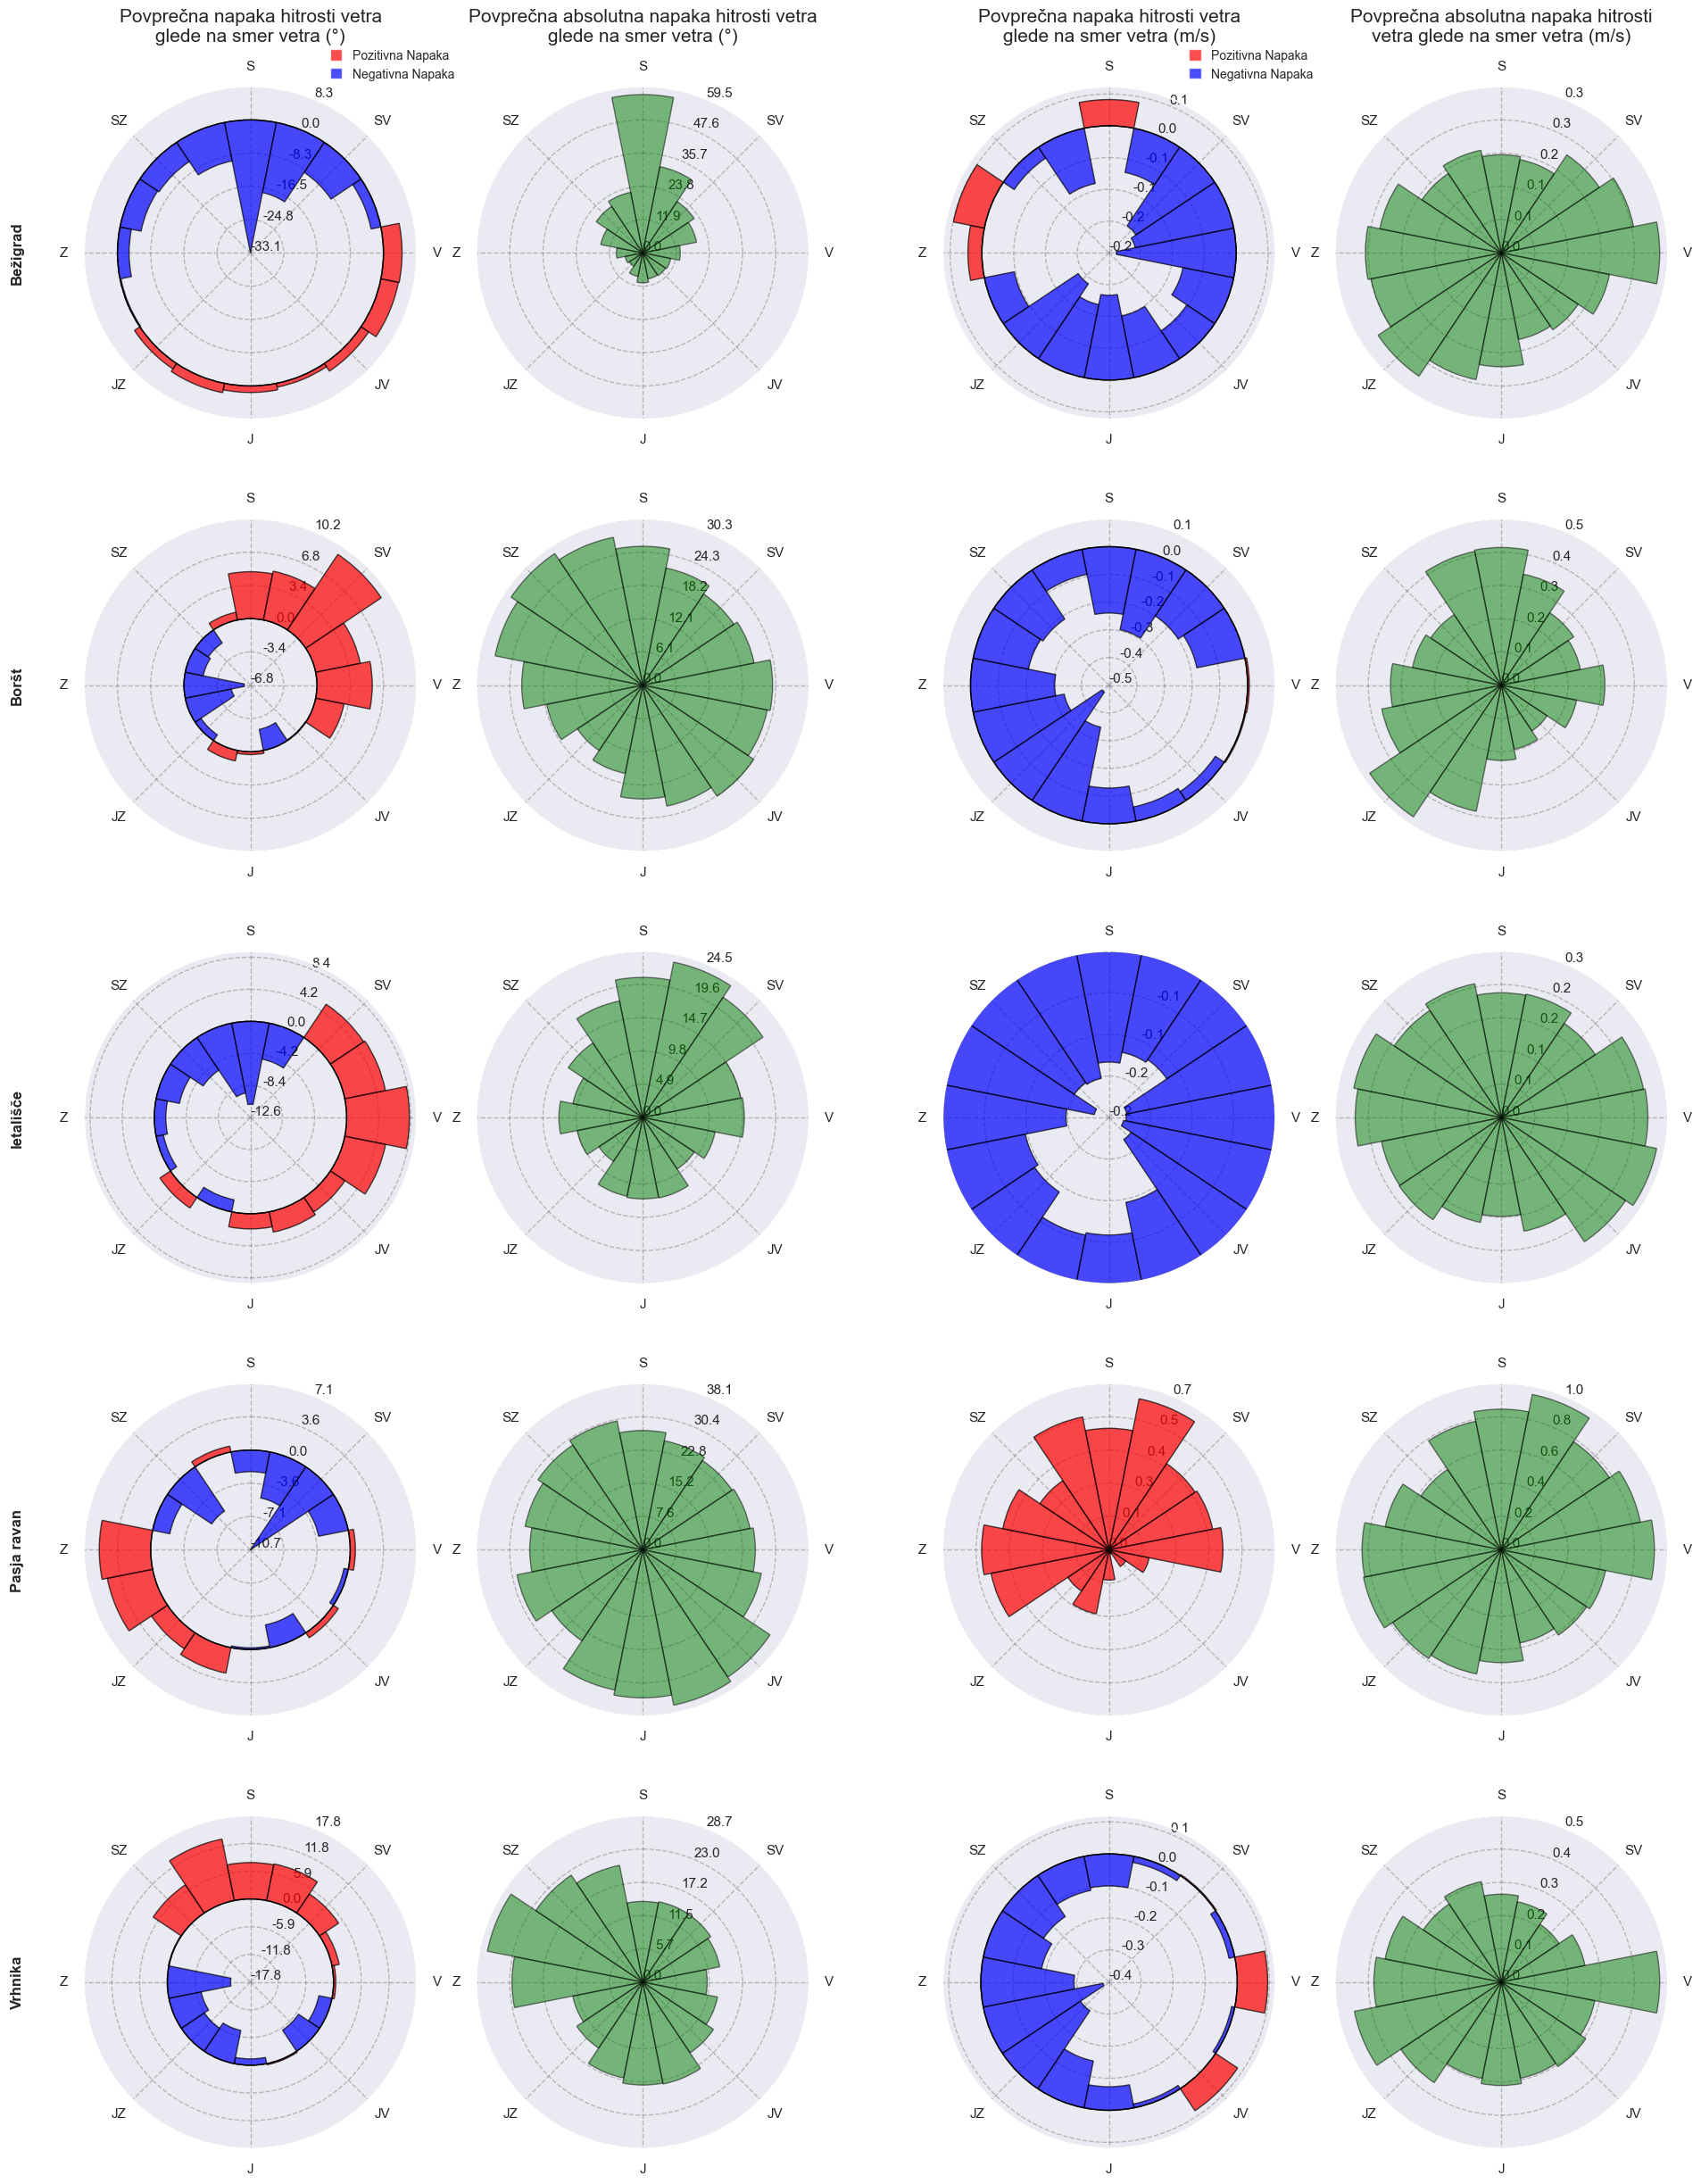

In [25]:
compare_wind_plots_for_stations(df_both, [s for s in stations])

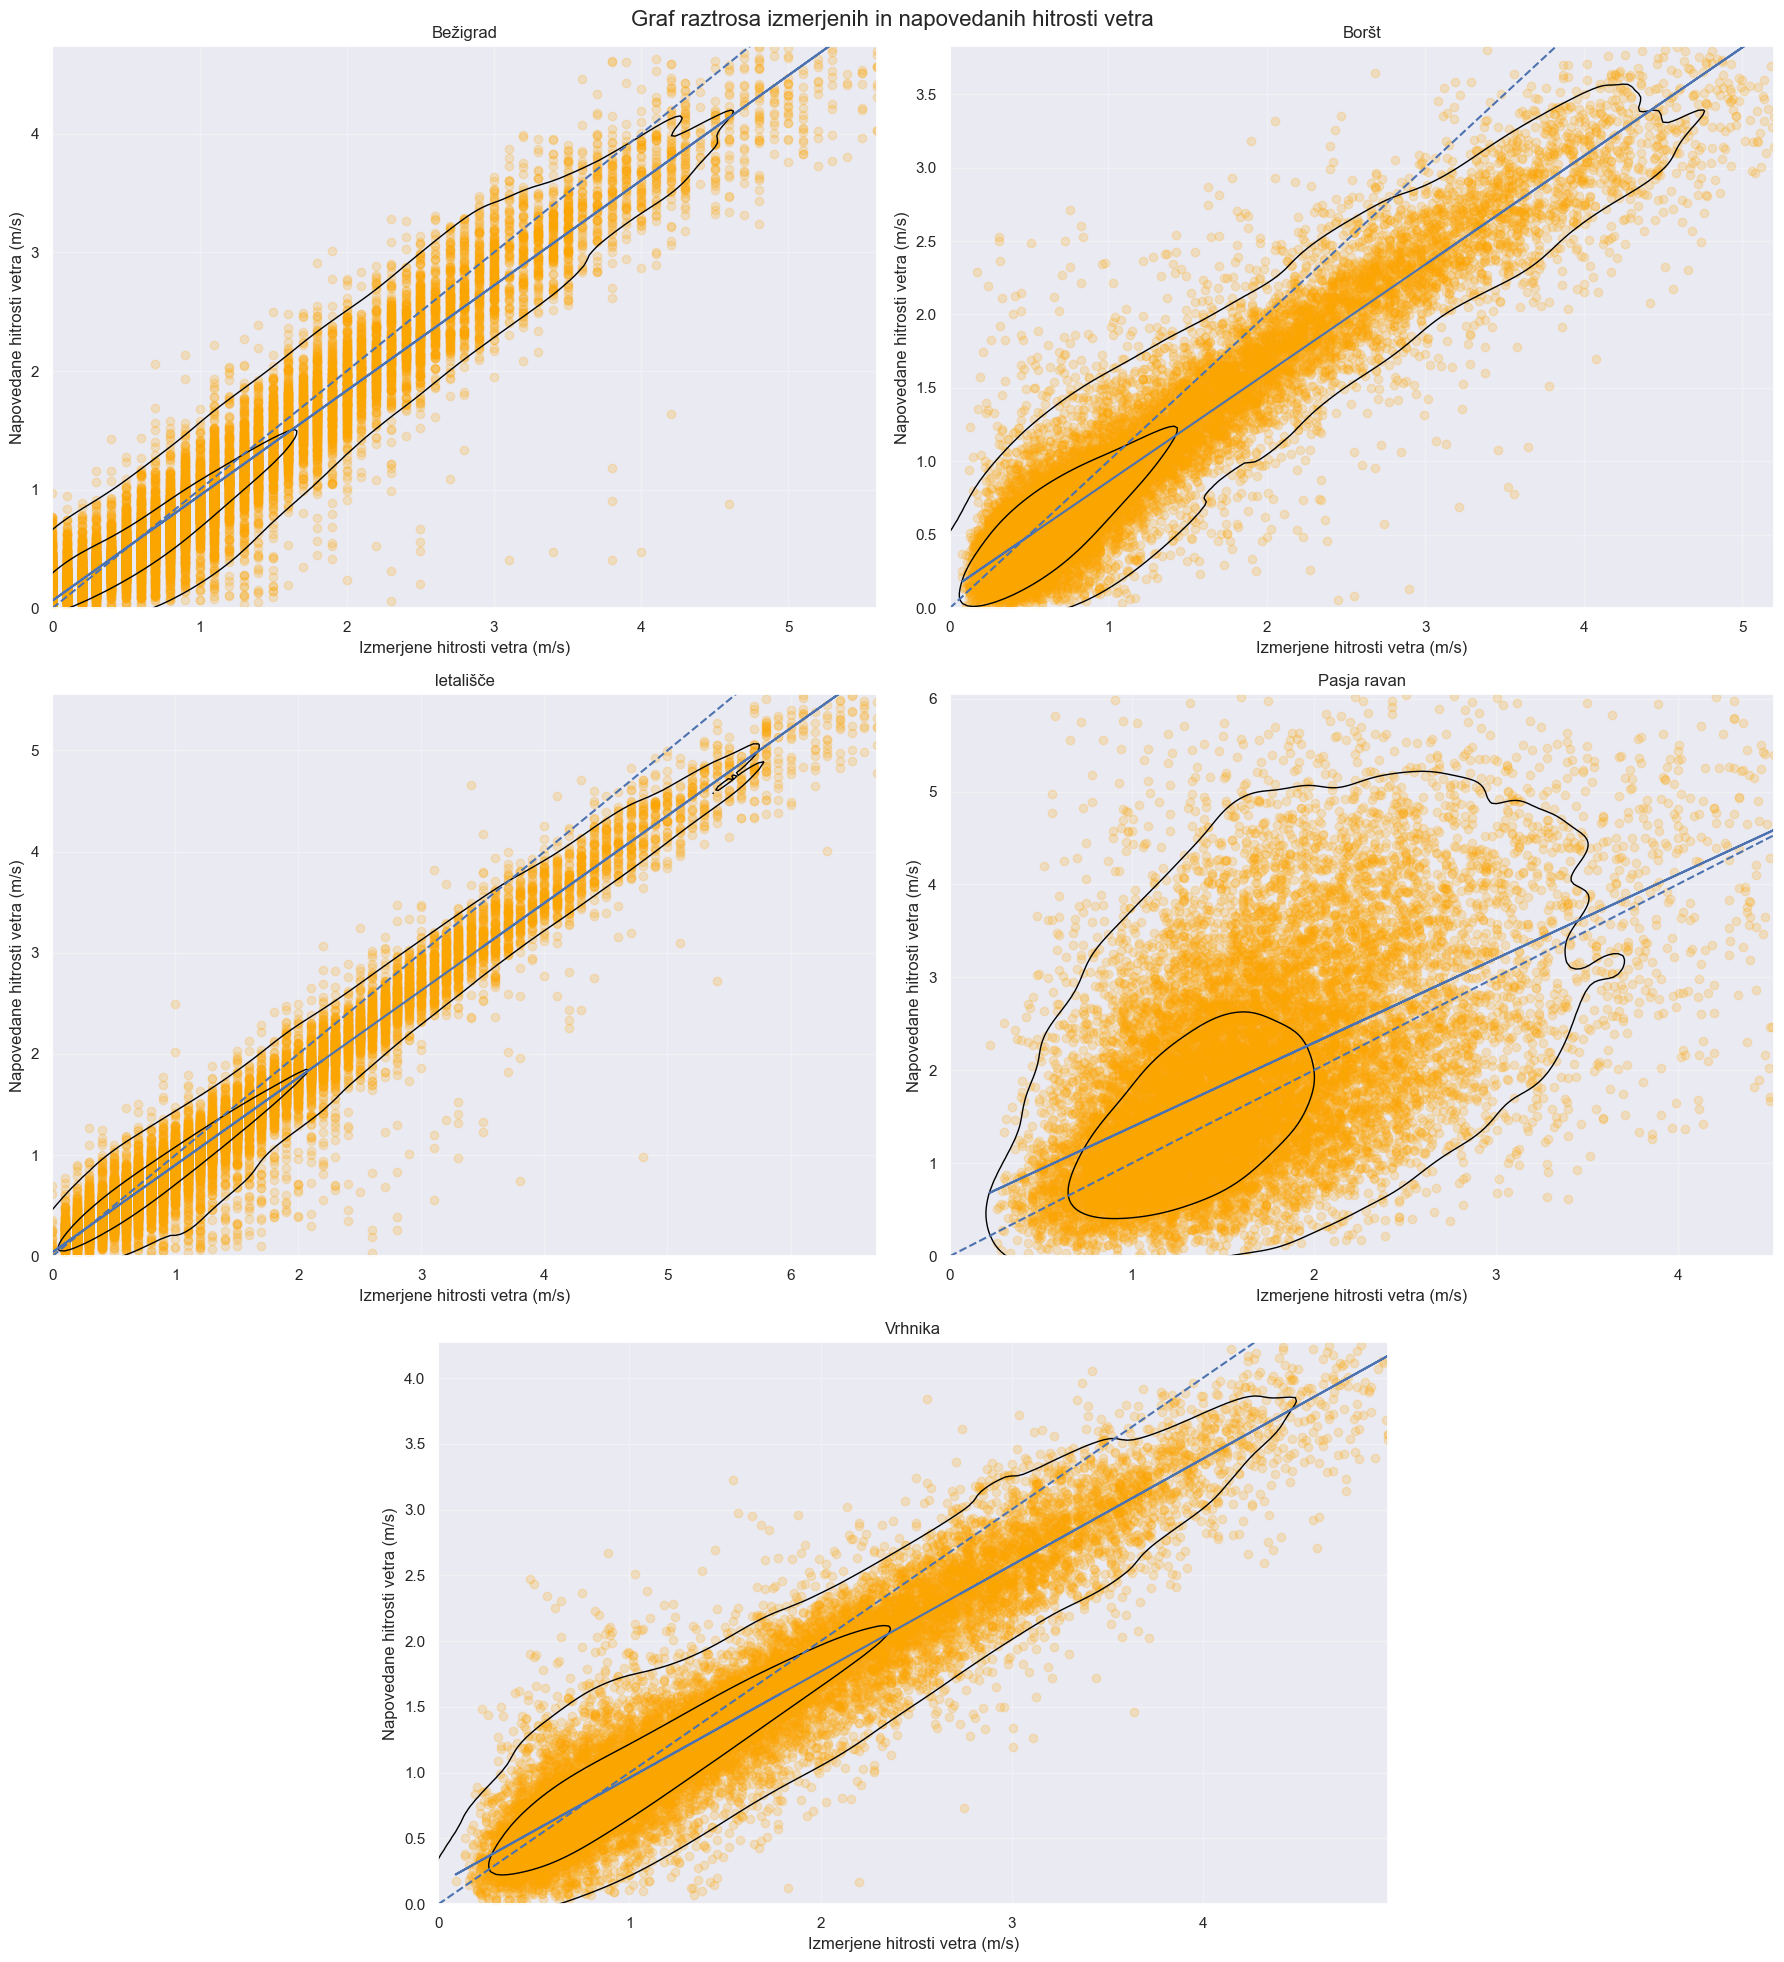

In [26]:
plot_wind_speed_comparison(df_both, stations, names)

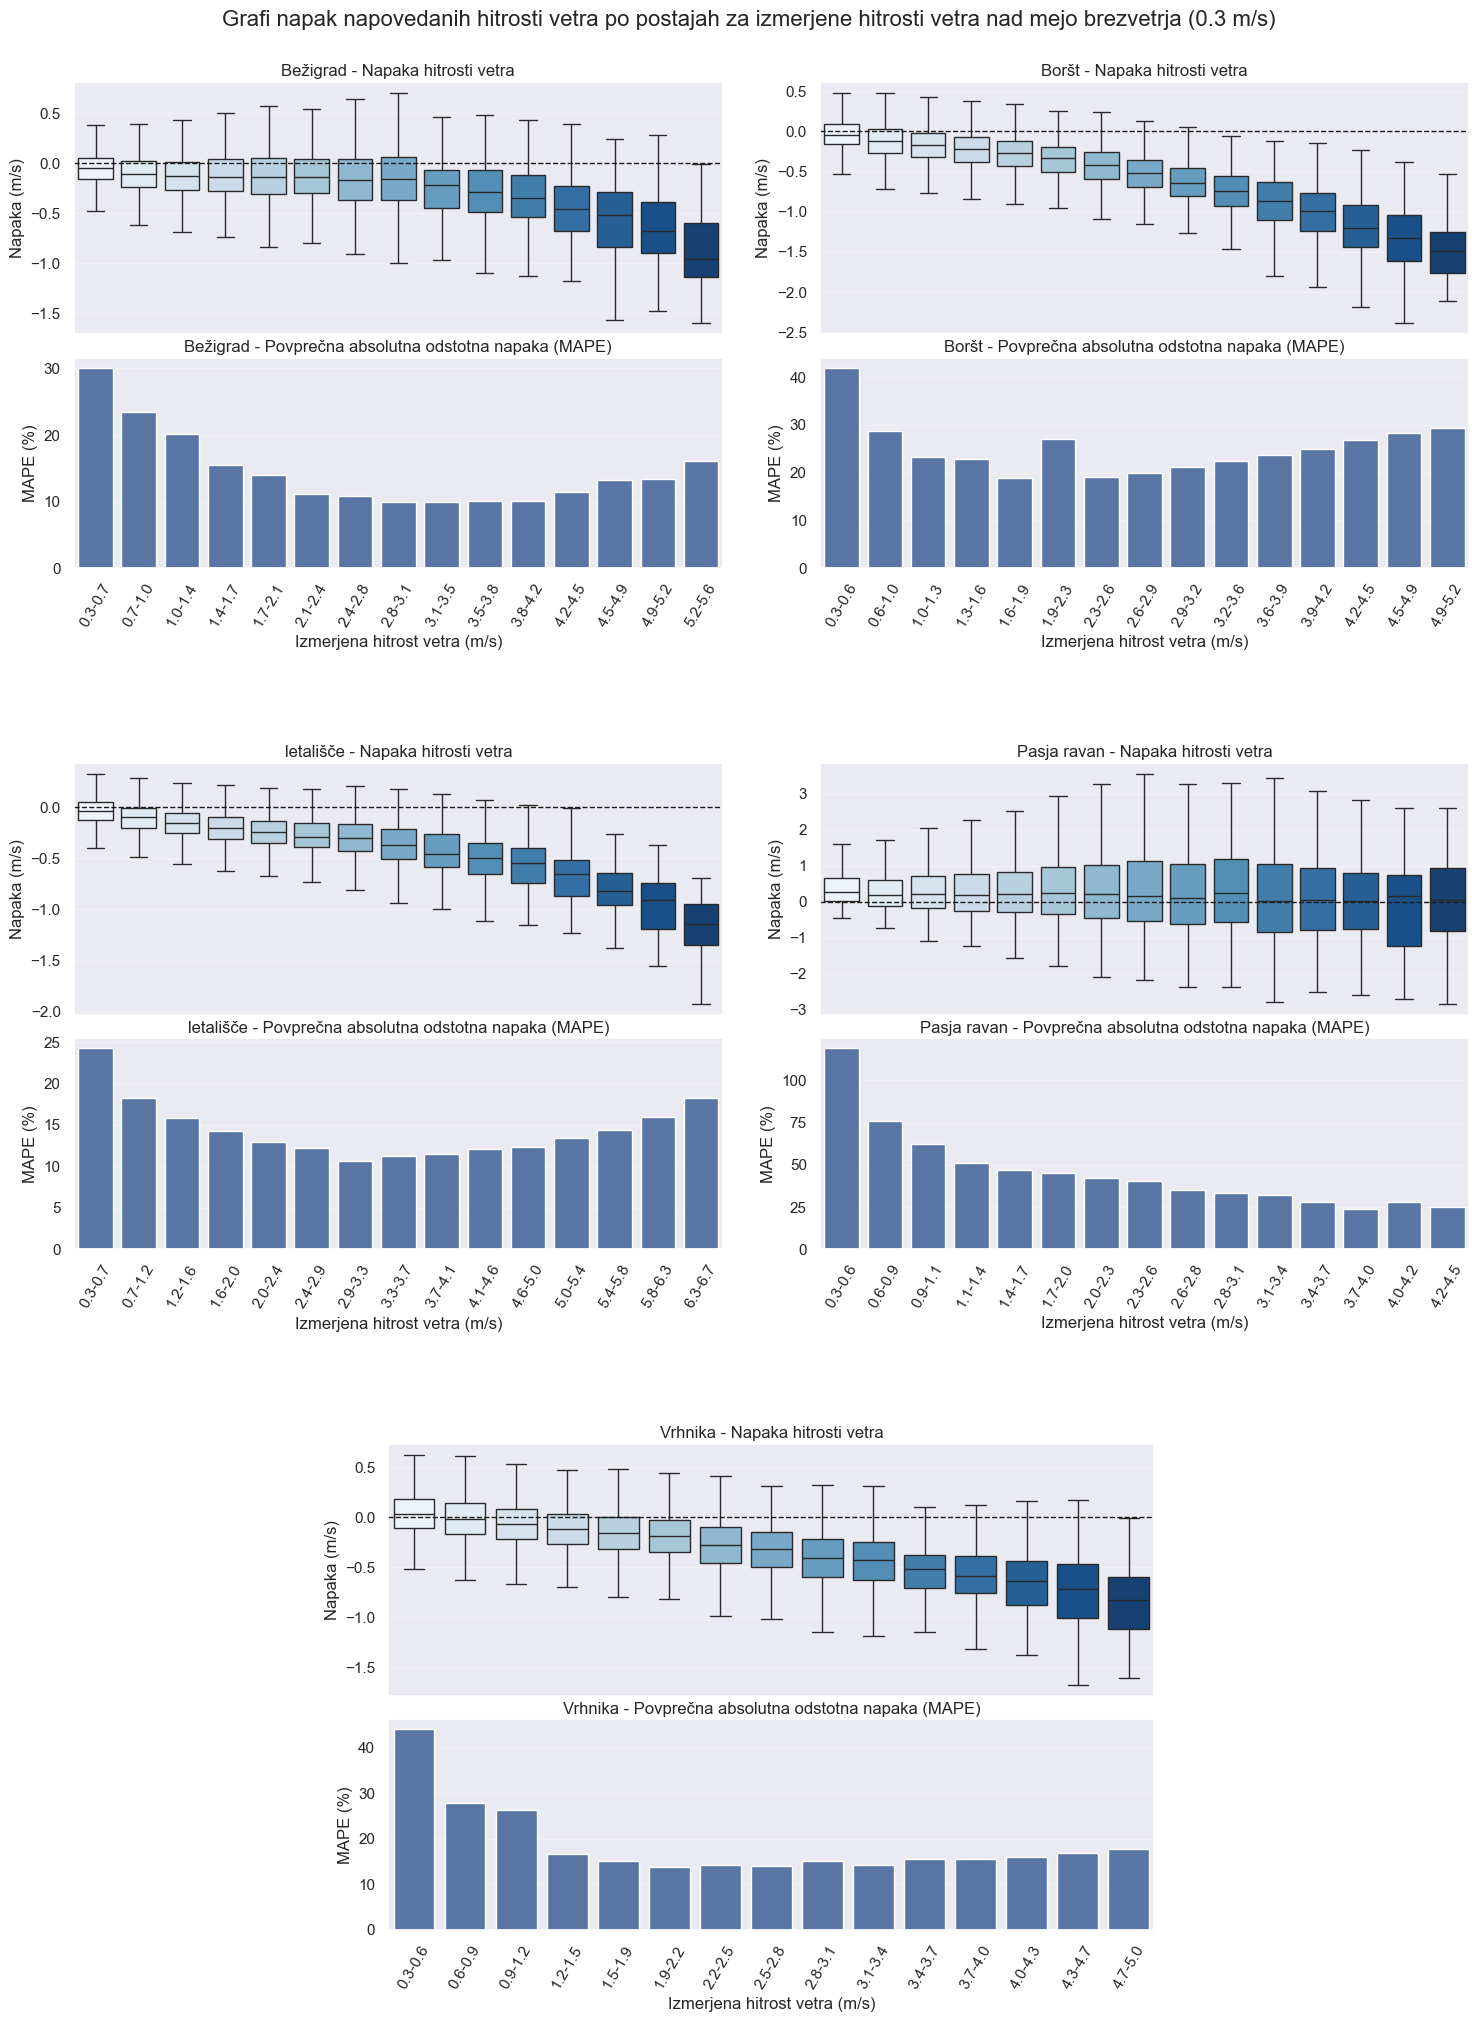

In [27]:
plot_wind_errors_all_stations(df=df_both, stations=[s for s in stations], names=names, num_bins=15, min_wspeed=0.3)

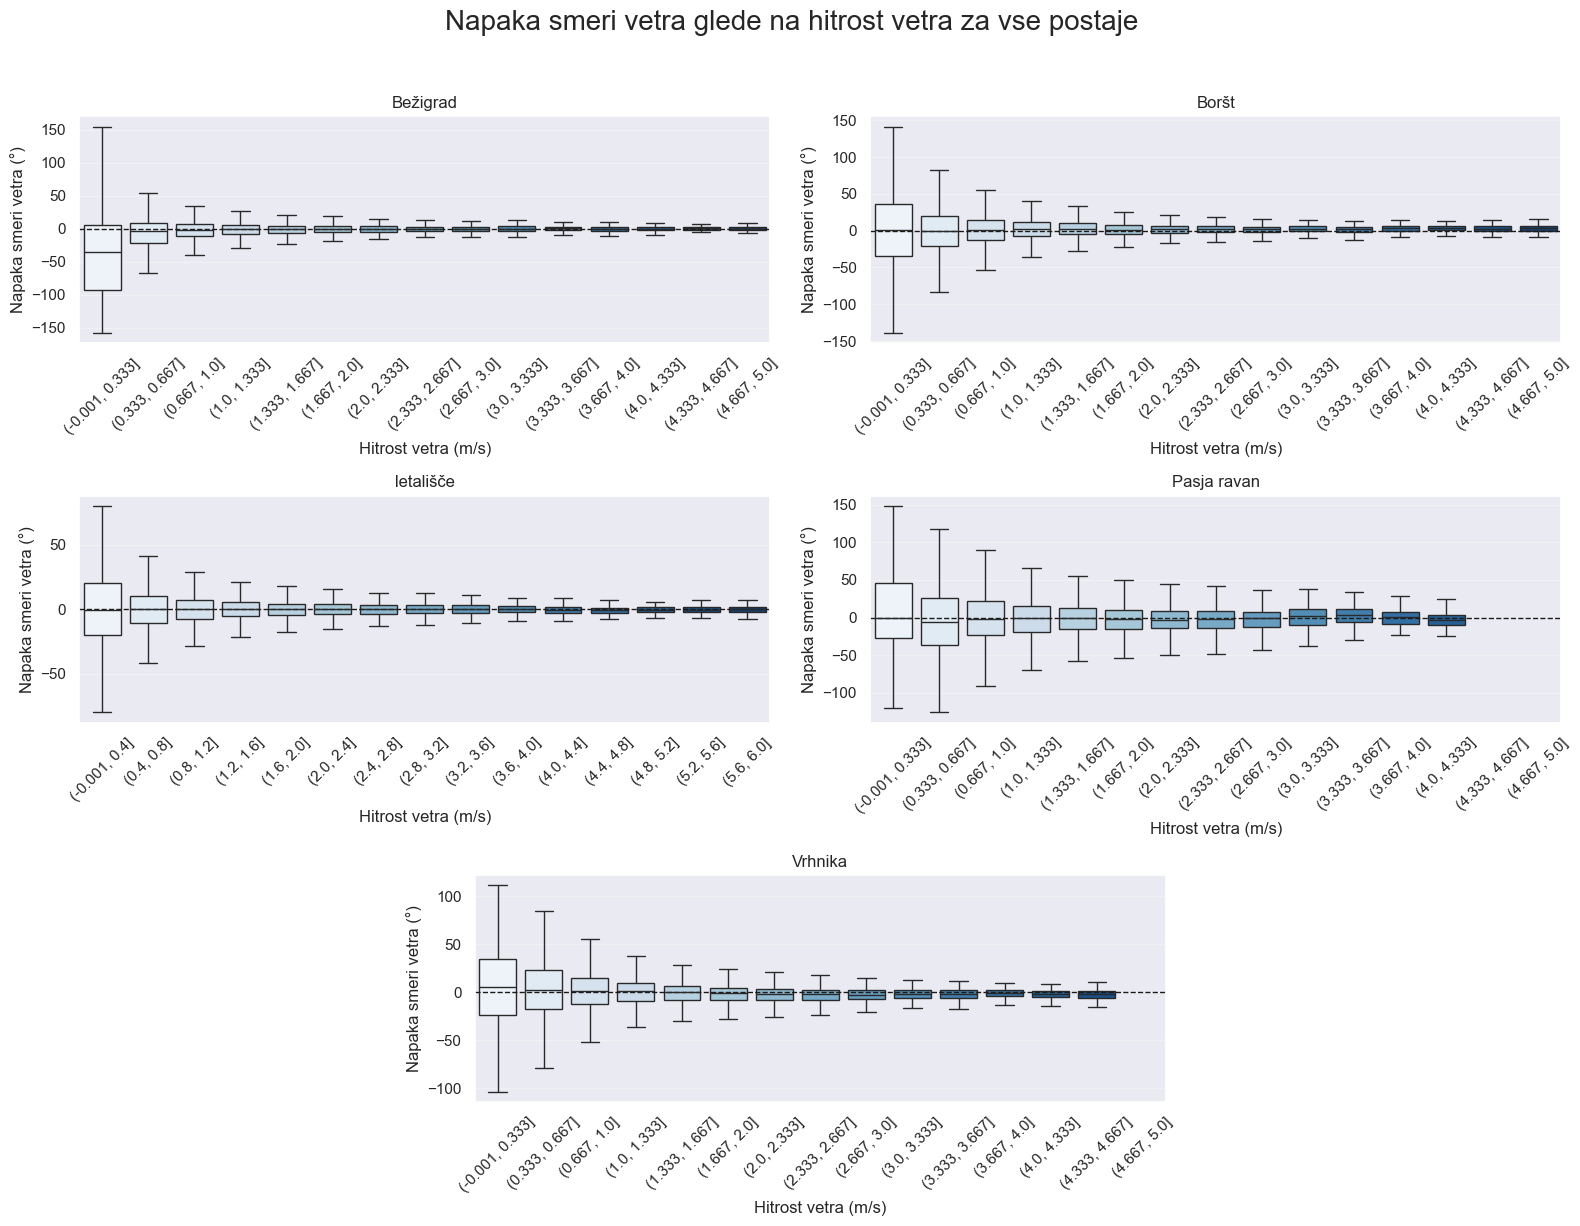

In [28]:
plot_wdir_error_by_wspeed_all_stations(df_both, stations, num_bins=15, names=names)

<Figure size 1400x1500 with 0 Axes>

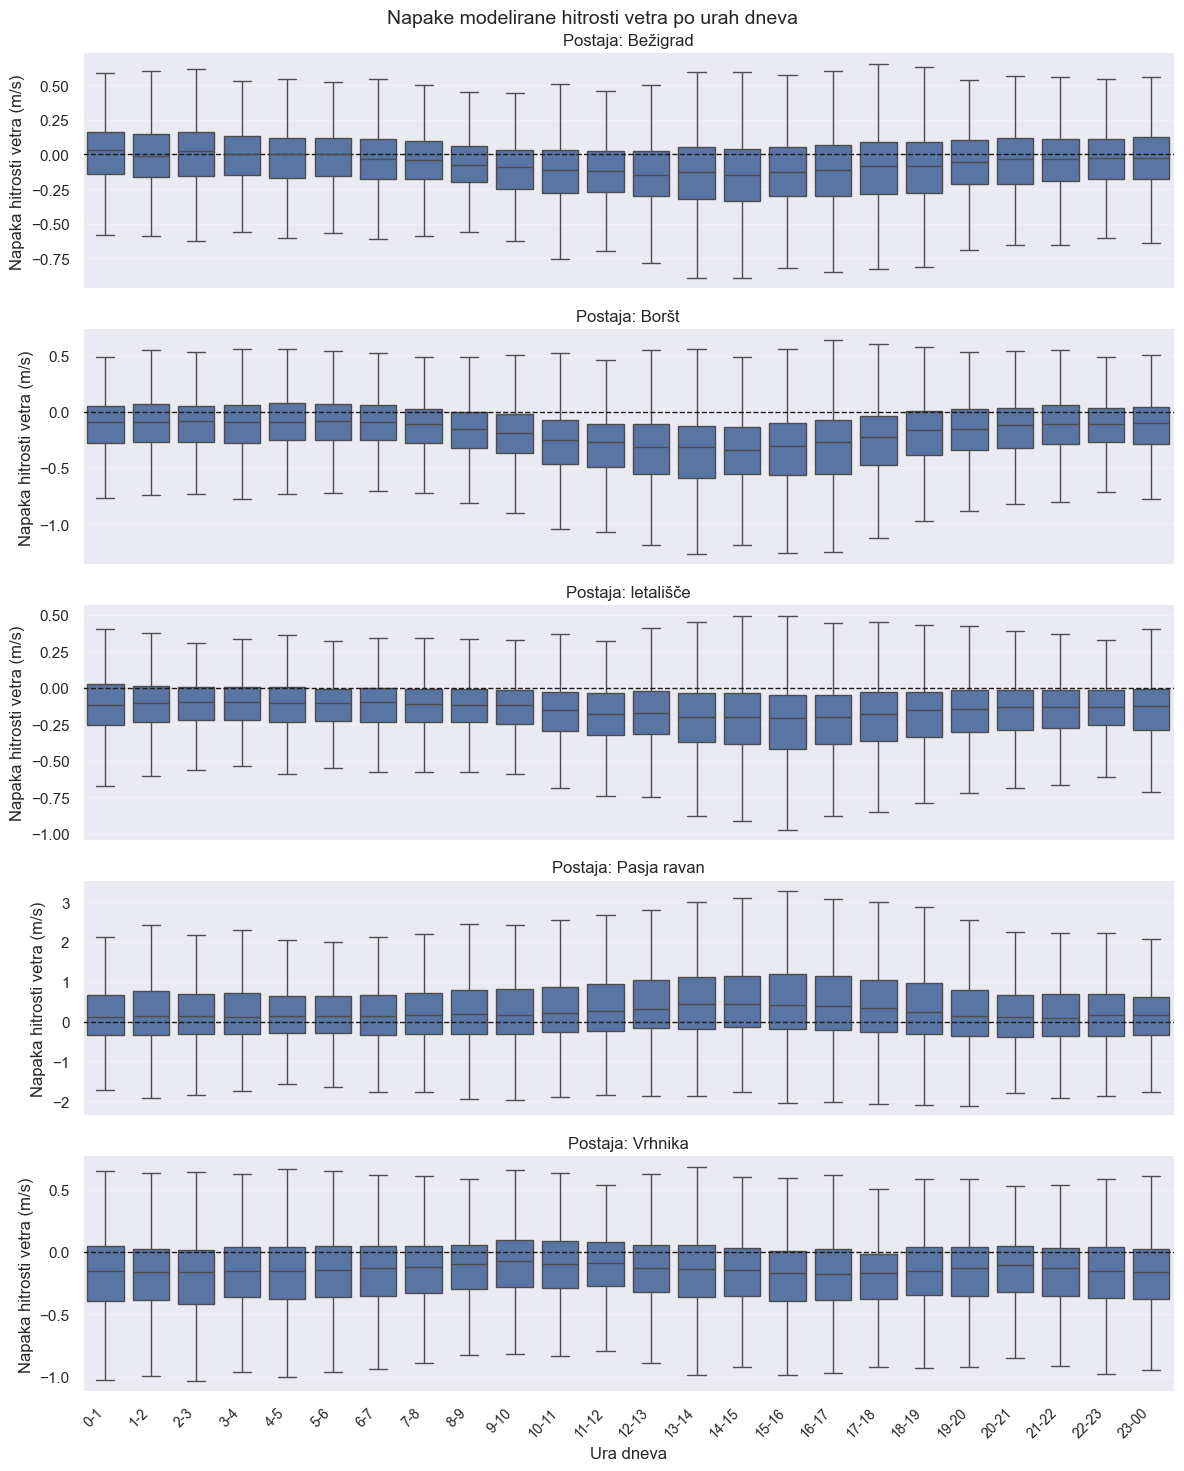

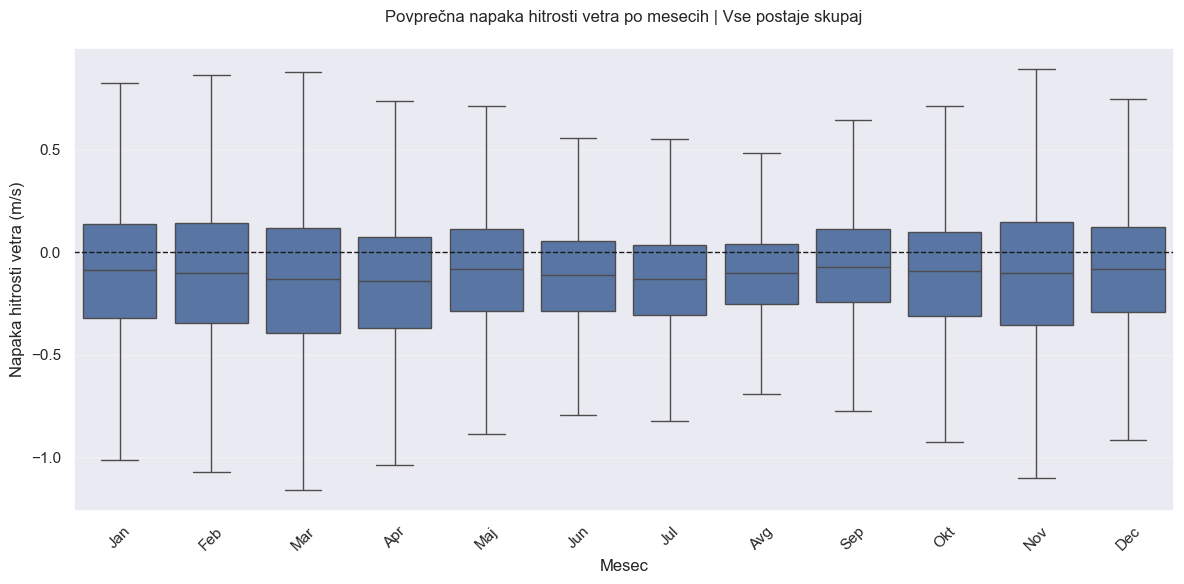

In [29]:
plot_wind_speed_error_by_hour_multistation(df_both, [s for s in stations], names=names)

plot_wind_speed_error_by_month_all_stations(df_both, [s for s in stations], names)

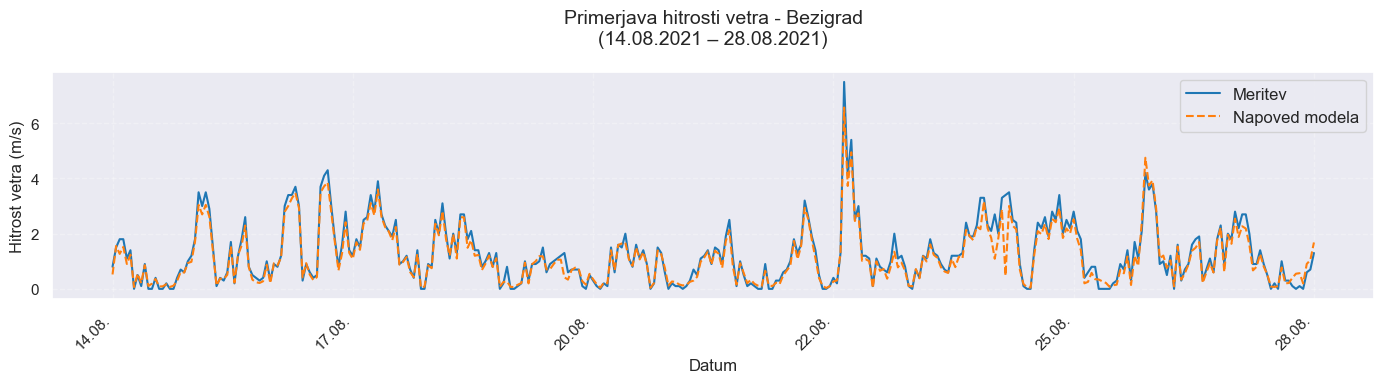

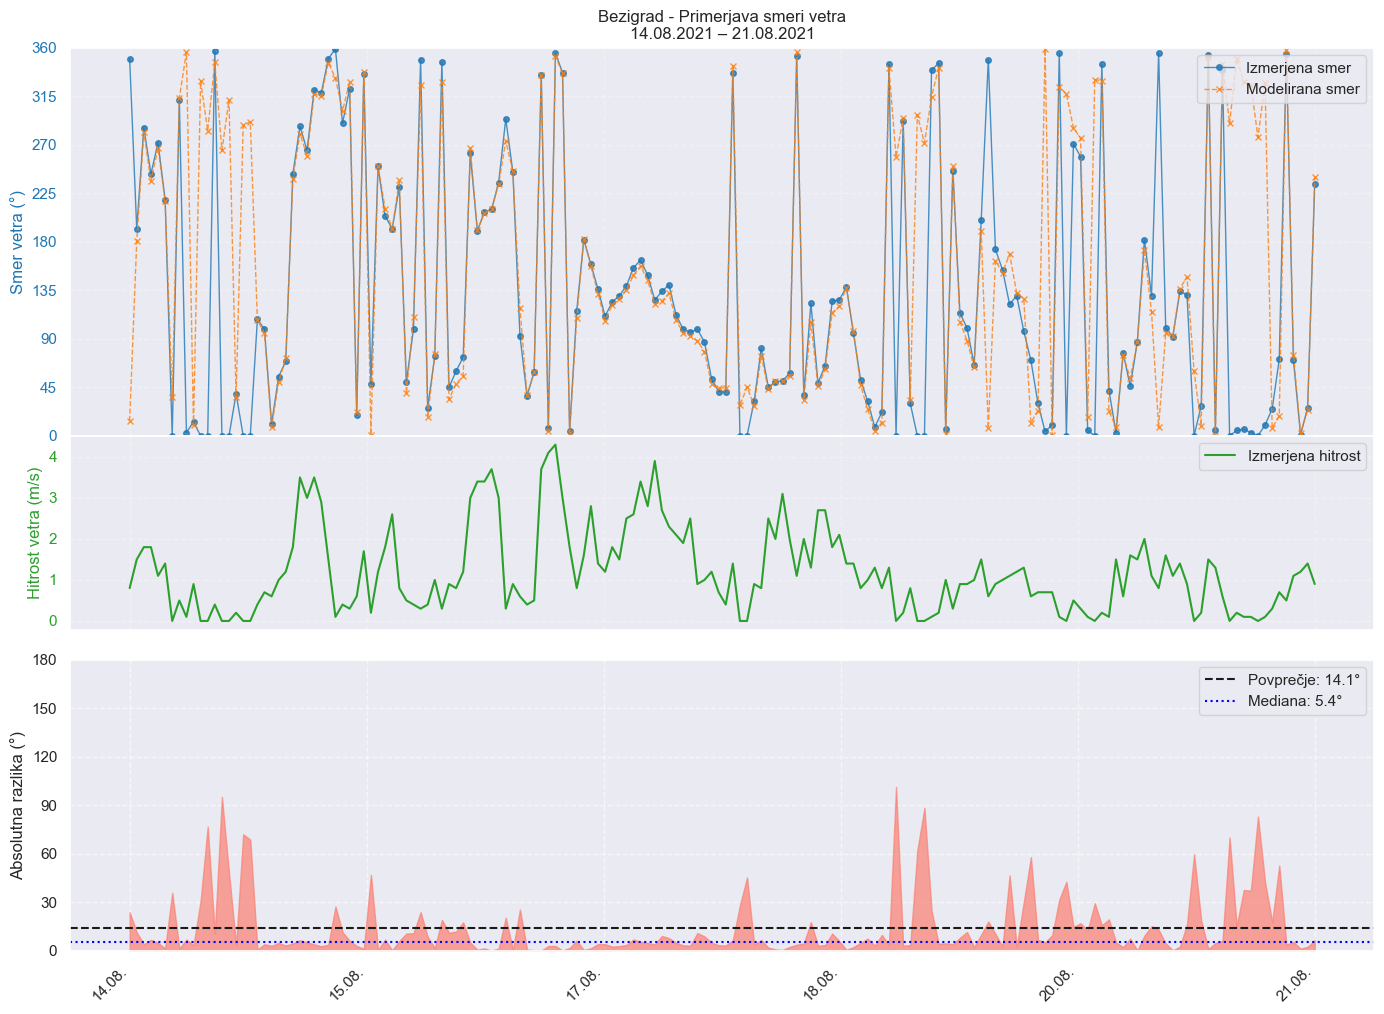

In [30]:
plot_wind_comparison(random.choice([df_2021, df_2023]), "bezigrad")